# NAFNet — Motion Deblurring and Denoising

Questo notebook addestra e valuta una rete NAFNet per ricostruire immagini degradate da motion blur e rumore gaussiano.

La degradazione usata è:

- motion blur con kernel `9x9`;
- angolo del blur pari a `45°`;
- rumore gaussiano con livelli `[0.005, 0.01, 0.05, 0.1]`.

Il test qualitativo mostra, per ogni immagine selezionata:

1. immagine pulita;
2. immagine degradata;
3. ricostruzione prodotta da NAFNet;

insieme a PSNR e SSIM.

In [ ]:
# 1 - Setup, dataset and model

from datasets import load_dataset
import torch
from torch.utils.data import Subset

from IPPy.utilities.metrics import PSNR, SSIM

from utilities.image_dataset import ImageDataset
from utilities.degradation import ImageDegradation, DegradationParameters
from utilities.plotter import plot 
from utilities.config import TRAIN_SIZE, VALIDATION_SIZE, TEST_SIZE, TO_RECONSTRUCT_INDEXES
from nafnet_heightmap.network_naf_net import NAFNet, NAFNetTrainer


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

IMAGE_SIZE = 256
IMAGE_SHAPE = (3, IMAGE_SIZE, IMAGE_SIZE)

NOISE_LEVELS = [0.005, 0.01, 0.05, 0.1]

CHECKPOINT_PATH = "./weights/NAFNet/NAFImgDeblur&Denoise.pth"

TRAIN_MODEL = True


ds = load_dataset("benjamin-paine/imagenet-1k-256x256")

train_dataset = Subset(
    ImageDataset(ds["train"]),
    range(TRAIN_SIZE),
)

validation_dataset = Subset(
    ImageDataset(ds["validation"]),
    range(VALIDATION_SIZE),
)

test_dataset = Subset(
    ImageDataset(ds["test"]),
    range(TEST_SIZE),
)


nafnet = NAFNet(
    image_shape=IMAGE_SHAPE,
    base_channels=32,
    enc_blocks=[1, 2, 3, 4],
    dec_blocks=[2, 2, 2, 1],
    middle_blocks=6,
).to(DEVICE)

naftrainer = NAFNetTrainer(nafnet)

Resolving data files:   0%|          | 0/40 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/40 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/36 [00:00<?, ?it/s]

## Training

La rete viene addestrata sulla stessa famiglia di degradazioni usata poi in fase di test.

Durante il training, il livello di rumore viene scelto tra i valori definiti in `NOISE_LEVELS`.  
Per la validazione vengono invece create quattro degradazioni separate, una per ciascun livello di rumore, così da osservare il comportamento della rete in condizioni controllate.

In [3]:
# 2 - Training

train_degradation = ImageDegradation(
    DegradationParameters(
        image_size=IMAGE_SIZE,
        kernel_type="motion",
        kernel_size=9,
        motion_angle=45,
        noise_levels=NOISE_LEVELS,
    )
)

validation_degradations = [
    ImageDegradation(
        DegradationParameters(
            image_size=IMAGE_SIZE,
            kernel_type="motion",
            kernel_size=9,
            motion_angle=45,
            noise_levels=[noise_level],
        )
    )
    for noise_level in NOISE_LEVELS
]


if TRAIN_MODEL:
    naf_history = naftrainer.train_model(
        n_epochs=50,
        train_dataset=train_dataset,
        validation_dataset=validation_dataset,
        train_degradation=train_degradation,
        validation_degradations=validation_degradations,
        batch_size=16,
        learning_rate=1e-4,
        checkpoint_path=CHECKPOINT_PATH,
        resume=True,
        preview_every=5,
        preview_n=1,
    )

Resumed NAFNet training from epoch 50


## Evaluation

Per la fase di valutazione viene caricato il checkpoint salvato durante il training.

Per ogni immagine di test selezionata vengono generate quattro diverse degradazioni, corrispondenti ai livelli di rumore definiti in `NOISE_LEVELS`. Per ogni caso vengono mostrate:

- immagine originale;
- immagine degradata;
- ricostruzione ottenuta tramite NAFNet.

La qualità della ricostruzione viene valutata attraverso PSNR e SSIM rispetto all'immagine pulita.

Loaded checkpoint: ./weights/NAFNet/NAFImgDeblur&Denoise.pth
Epoch: 49
Best validation loss: 0.03877361662307521


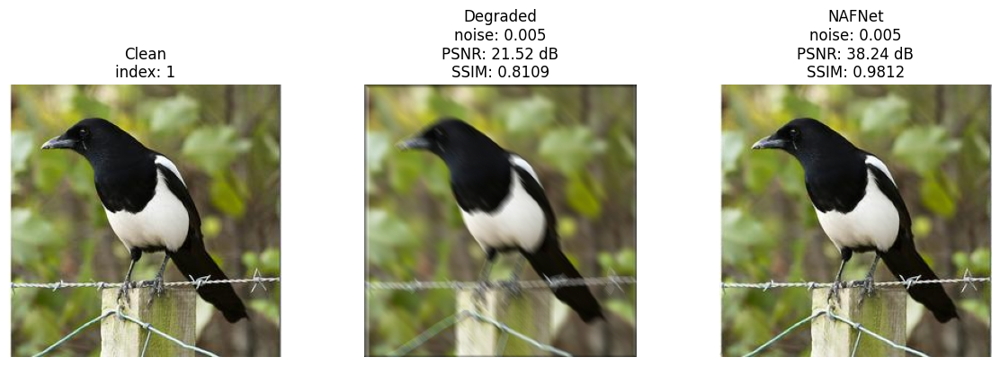

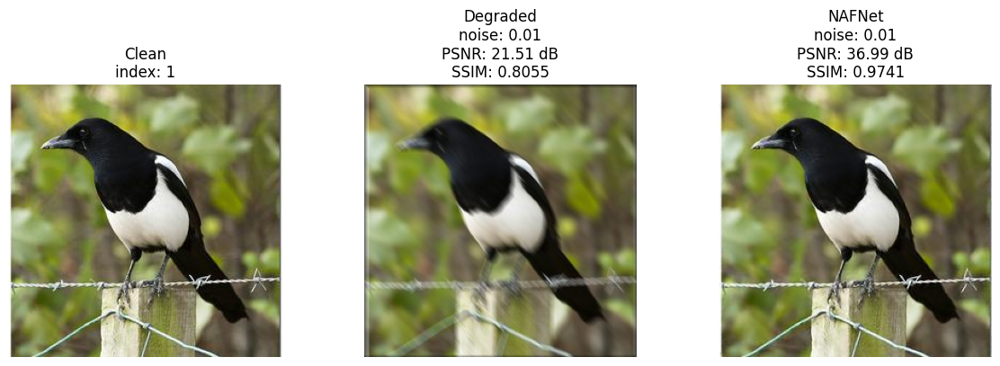

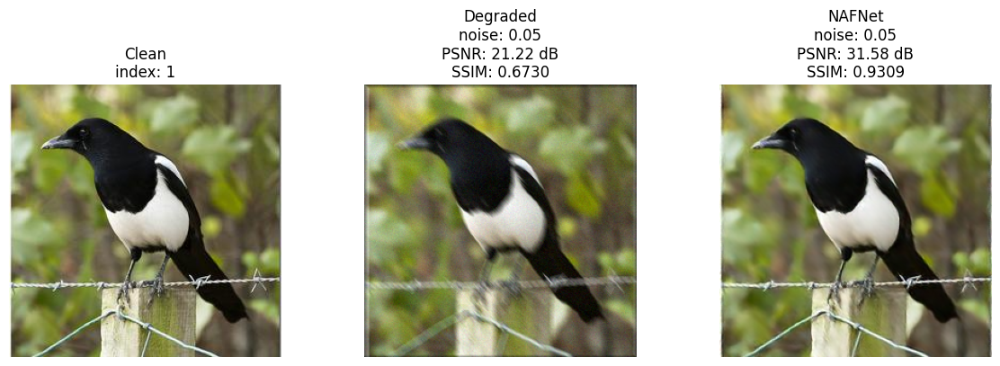

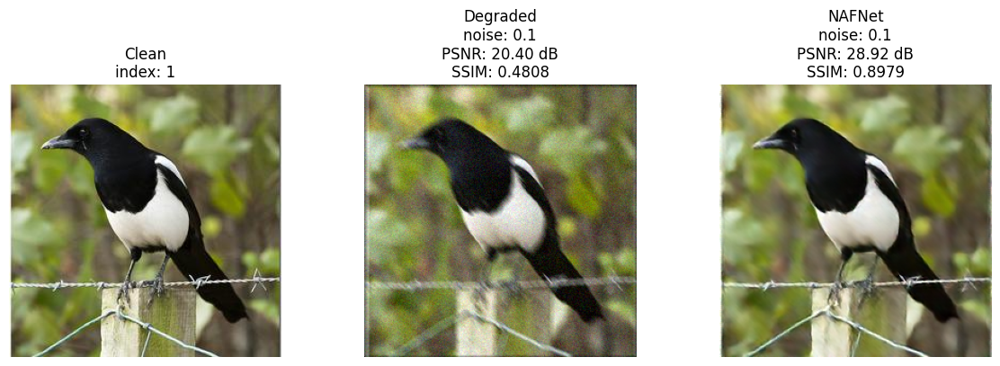

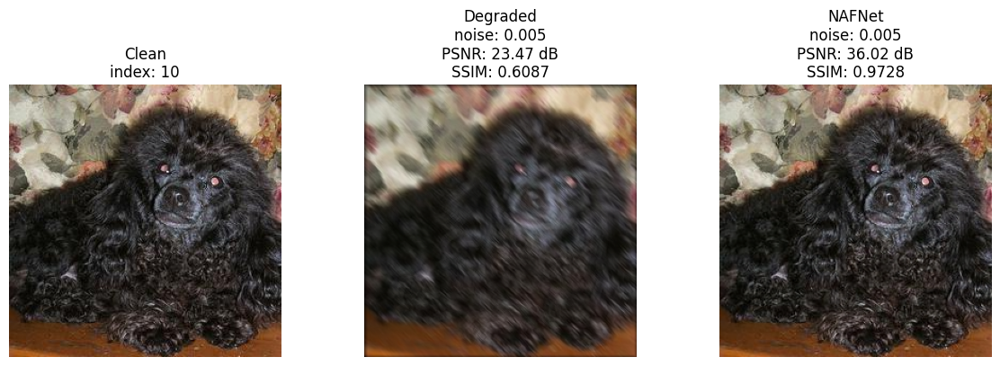

...

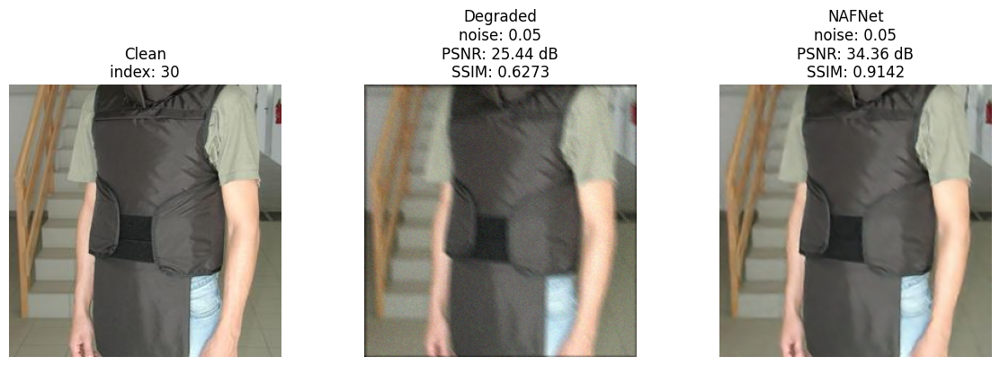

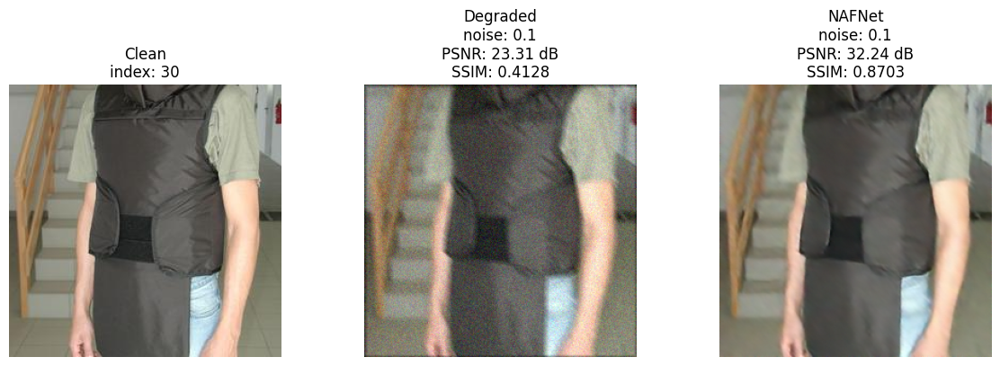

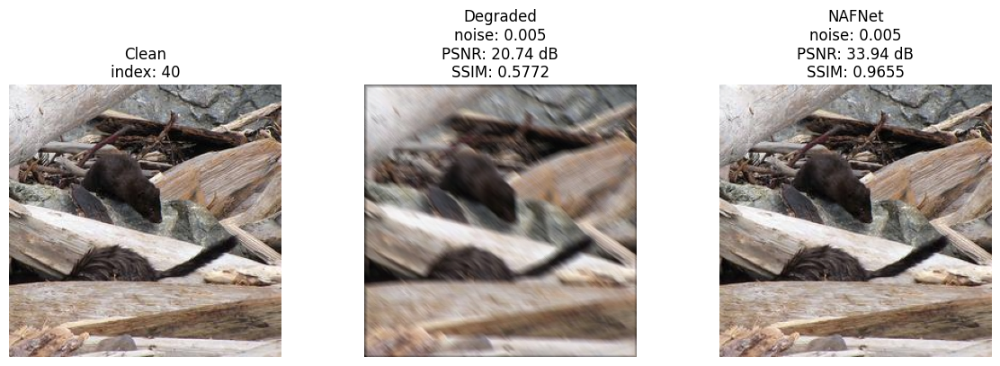

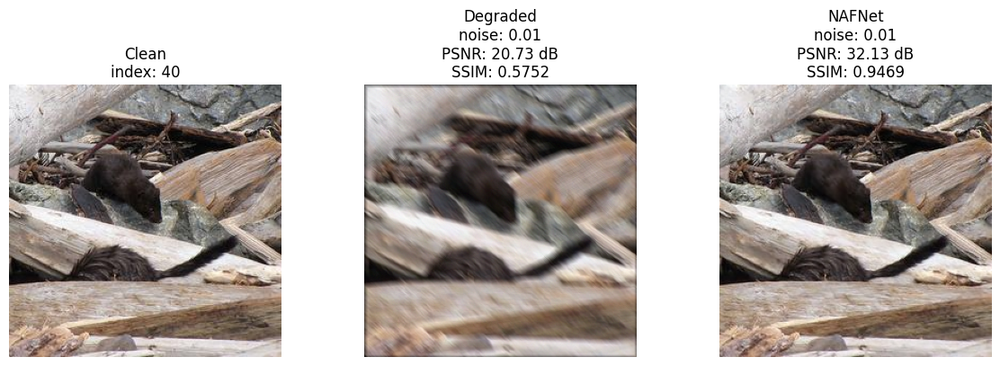

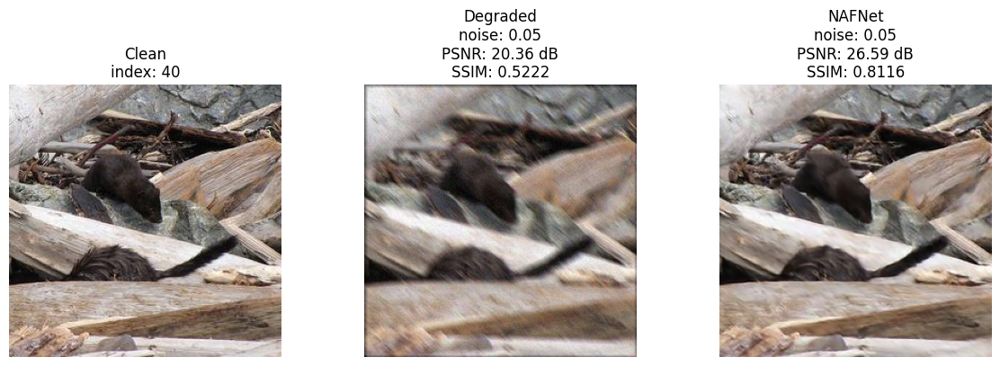

KeyboardInterrupt: 

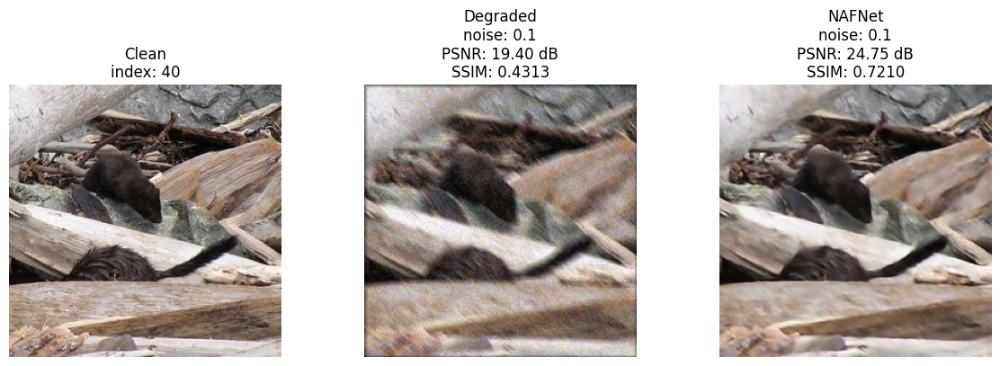

In [3]:
# 3 - Load checkpoint and qualitative evaluation

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=DEVICE,
    weights_only=False,
)

nafnet.load_state_dict(
    checkpoint["model"],
    strict=True,
)

nafnet.eval()

for parameter in nafnet.parameters():
    parameter.requires_grad = False


print(f"Loaded checkpoint: {CHECKPOINT_PATH}")
print(f"Epoch: {checkpoint.get('epoch')}")
print(f"Best validation loss: {checkpoint.get('best_validation_loss')}")


with torch.no_grad():
    for image_index in TO_RECONSTRUCT_INDEXES:
        clean = test_dataset[image_index].unsqueeze(0).to(DEVICE)

        for noise_level in NOISE_LEVELS:
            degradation = ImageDegradation(
                DegradationParameters(
                    image_size=IMAGE_SIZE,
                    kernel_type="motion",
                    kernel_size=9,
                    motion_angle=45,
                    noise_levels=[noise_level],
                )
            )

            degraded = degradation(clean)
            reconstructed = nafnet(degraded).clamp(0, 1)

            psnr_degraded = PSNR(degraded, clean)
            ssim_degraded = SSIM(degraded, clean)

            psnr_reconstructed = PSNR(reconstructed, clean)
            ssim_reconstructed = SSIM(reconstructed, clean)

            plot(
                clean,
                degraded,
                reconstructed,
                titles=[
                    f"Clean\nindex: {image_index}",
                    (
                        f"Degraded\n"
                        f"noise: {noise_level}\n"
                        f"PSNR: {psnr_degraded:.2f} dB\n"
                        f"SSIM: {ssim_degraded:.4f}"
                    ),
                    (
                        f"NAFNet\n"
                        f"noise: {noise_level}\n"
                        f"PSNR: {psnr_reconstructed:.2f} dB\n"
                        f"SSIM: {ssim_reconstructed:.4f}"
                    ),
                ],
                size=4,
                save_path=(
                    "results/NAFNet/"
                    f"noise_{int(noise_level * 1000):03d}/"
                    f"image_{image_index}.png"
                ),
            )

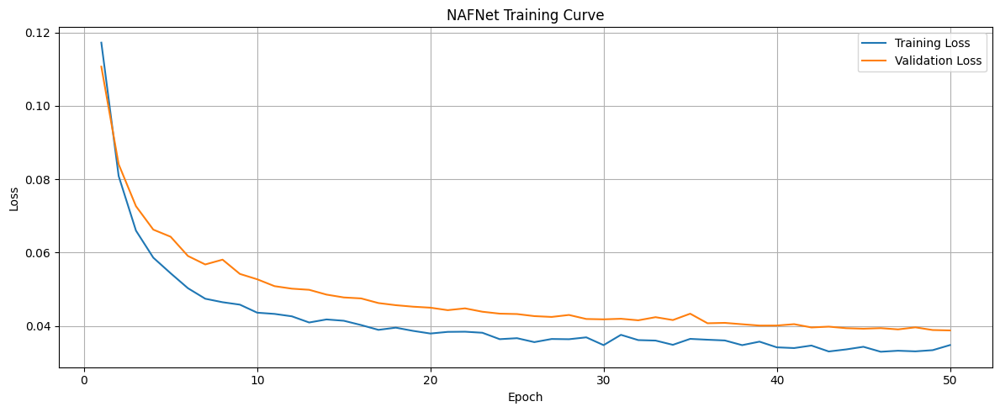

In [6]:
import matplotlib.pyplot as plt

epochs = range(1, len(naf_history["train_loss"]) + 1)

plt.figure(figsize=(12, 5))

plt.plot(
    epochs,
    naf_history["train_loss"],
    label="Training Loss",
)

plt.plot(
    epochs,
    naf_history["validation_loss"],
    label="Validation Loss",
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("NAFNet Training Curve")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

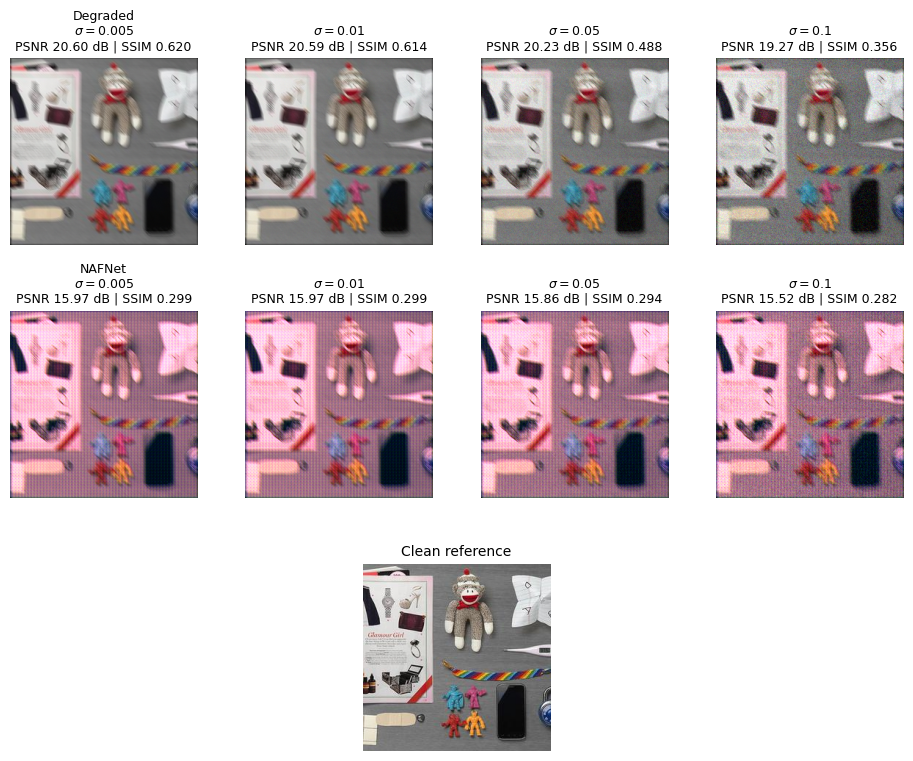

Saved grid to: results/NAFNet/evaluation_grid_image_80.png


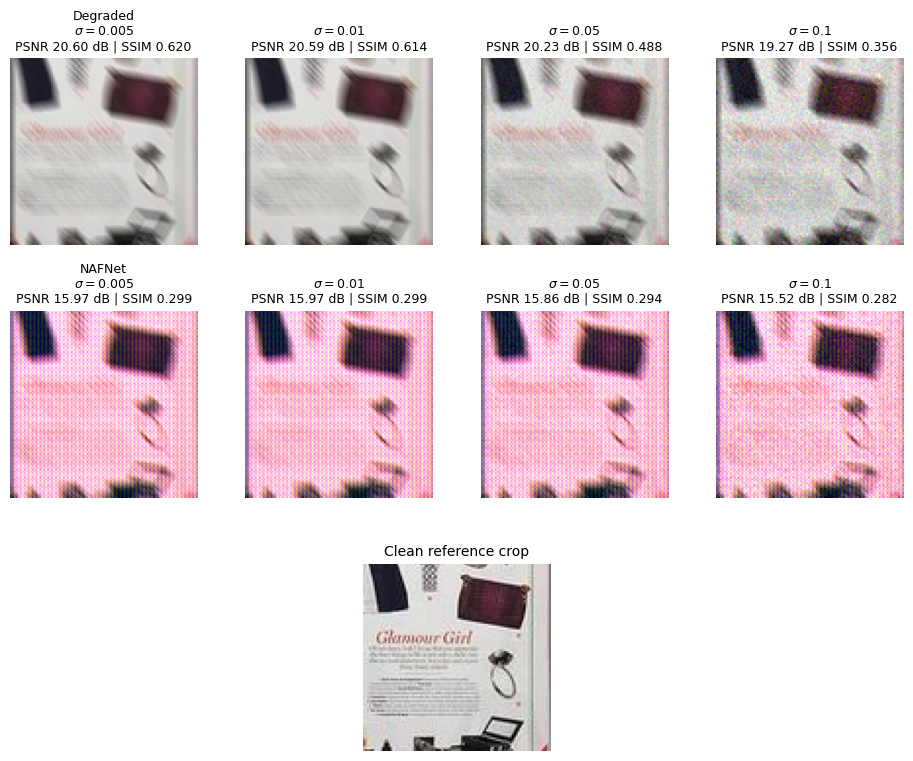

Saved grid to: results/NAFNet/evaluation_grid_image_80_crop.png


In [2]:
# NAFNet qualitative evaluation: full image + crop
# Network inference is computed only once per noise level

import os
import torch
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

image_index = 80
base_dir = "results/NAFNet"

save_path_full = f"{base_dir}/evaluation_grid_image_{image_index}.png"
save_path_crop = f"{base_dir}/evaluation_grid_image_{image_index}_crop.png"

# Crop format: (x0, y0, width, height)
crop_box = (0, 60, 96, 96)

def crop_tensor(img, crop_box):
    x0, y0, w, h = crop_box
    return img[..., y0:y0 + h, x0:x0 + w]

def to_numpy_image(tensor):
    return (
        tensor.detach()
        .cpu()
        .squeeze(0)
        .permute(1, 2, 0)
        .clamp(0.0, 1.0)
    )

def scalar(value):
    return value.item() if isinstance(value, torch.Tensor) else value

def plot_evaluation_grid(clean_img, results, save_path, crop_box=None, title_suffix=""):
    if crop_box is not None:
        clean_to_show = crop_tensor(clean_img, crop_box)
    else:
        clean_to_show = clean_img

    fig = plt.figure(figsize=(12, 9))

    gs = GridSpec(
        3,
        len(results),
        figure=fig,
        height_ratios=[1, 1, 1],
        hspace=0.35,
        wspace=0.05,
    )

    for col, result in enumerate(results):
        degraded = result["degraded"]
        reconstructed = result["reconstructed"]

        if crop_box is not None:
            degraded = crop_tensor(degraded, crop_box)
            reconstructed = crop_tensor(reconstructed, crop_box)

        pairs = [
            ("Degraded", degraded, result["psnr_d"], result["ssim_d"], 0),
            ("NAFNet", reconstructed, result["psnr_r"], result["ssim_r"], 1),
        ]

        for label, tensor, psnr_value, ssim_value, row in pairs:
            ax = fig.add_subplot(gs[row, col])
            ax.imshow(to_numpy_image(tensor))
            ax.axis("off")

            title = (
                f"$\\sigma={result['noise_level']}$\n"
                f"PSNR {psnr_value:.2f} dB | SSIM {ssim_value:.3f}"
            )

            if col == 0:
                title = f"{label}\n" + title

            ax.set_title(title, fontsize=9, pad=6)

    clean_ax = fig.add_subplot(gs[2, 1:3])
    clean_ax.imshow(to_numpy_image(clean_to_show))
    clean_ax.set_title(f"Clean reference{title_suffix}", fontsize=10, pad=6)
    clean_ax.axis("off")

    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()
    print(f"Saved grid to: {save_path}")

nafnet.eval()

for parameter in nafnet.parameters():
    parameter.requires_grad = False

clean = test_dataset[image_index].unsqueeze(0).to(DEVICE)

results = []

with torch.no_grad():
    for noise_level in NOISE_LEVELS:
        degradation = ImageDegradation(
            DegradationParameters(
                image_size=IMAGE_SIZE,
                kernel_type="motion",
                kernel_size=9,
                motion_angle=45,
                noise_levels=[noise_level],
            )
        )

        degraded = degradation(clean)
        reconstructed = nafnet(degraded).clamp(0.0, 1.0)

        psnr_d = scalar(PSNR(degraded, clean))
        ssim_d = scalar(SSIM(degraded, clean))

        psnr_r = scalar(PSNR(reconstructed, clean))
        ssim_r = scalar(SSIM(reconstructed, clean))

        results.append(
            {
                "noise_level": noise_level,
                "degraded": degraded,
                "reconstructed": reconstructed,
                "psnr_d": psnr_d,
                "ssim_d": ssim_d,
                "psnr_r": psnr_r,
                "ssim_r": ssim_r,
            }
        )

plot_evaluation_grid(
    clean_img=clean,
    results=results,
    save_path=save_path_full,
)

plot_evaluation_grid(
    clean_img=clean,
    results=results,
    save_path=save_path_crop,
    crop_box=crop_box,
    title_suffix=" crop",
)